# 完全保存用の独立した再実行

このNotebookは notebooks/10_svd/30_fashion_mnist_cnn/05_cnn_conv_linear_svd_corrected.ipynb の新規run。過去runの復元ではなく、baseline重み・全rankの未丸め値・FT各epoch履歴・測定条件を新しい出力先へ保存する。元の説明・条件・TODOを保持し、変更は出力先・進捗ログ・保存用セルだけ。

元Notebook中の「未実行」「過去の欠落」は複製元runへの説明。以下の新規runの実行状態は末尾のrun_manifest.jsonと各セルのexecution_countで確認する。

実行後の命名整理：Notebook名とEXPERIMENT_NAMEを `_rerun` に揃え、results/modelsの対応ディレクトリも改名した。学習・評価は再実行していない。セルの出力ログにある日時付き旧パスは実行当時の記録であり、現在の保存先はEXPERIMENT_NAMEとrun_manifest.jsonの各pathを参照する。数値・図・execution_countは改名前の実行結果を保持する。


In [1]:
# 独立した新規run。元Notebook/CSV/重みを上書きしない。
import sys
from pathlib import Path
_run_root = Path.cwd().resolve()
while not (_run_root / "src" / "nn_compression").is_dir() and _run_root.parent != _run_root:
    _run_root = _run_root.parent
sys.path.insert(0, str(_run_root / "src"))
RUN_BATCH_ID = 'rerun_20260912T074153Z'
RUN_SOURCE_RELATIVE = 'notebooks/10_svd/30_fashion_mnist_cnn/05_cnn_conv_linear_svd_corrected.ipynb'
RUN_NOTEBOOK_RELATIVE = 'notebooks/10_svd/30_fashion_mnist_cnn/05_cnn_conv_linear_svd_corrected_rerun.ipynb'
RUN_SOURCE_SNAPSHOT_SHA256 = '34cfd80e1d6bc544c6d914705d193ccecdd9c13c2653372e4bf3590180a1a1c0'
print("独立新規run:", RUN_BATCH_ID, RUN_SOURCE_RELATIVE)


独立新規run: rerun_20260912T074153Z notebooks/10_svd/30_fashion_mnist_cnn/05_cnn_conv_linear_svd_corrected.ipynb


# 05_cnn_conv_linear_svd（corrected）

原本 `05_cnn_conv_linear_svd.ipynb` は実験履歴として残す。
この Notebook は現行 src の実験契約に合わせた修正版。

- 推論時間は `validation_loader_final` から取った同じ `input_batch` で測る
- warmup / repeats を baseline と compressed で揃える
- 出力先は `05_cnn_conv_linear_svd_corrected`
- Fine-tuning 前の `set_seed(SEED)` と `loader_generator.manual_seed(SEED)` は維持する

## corrected版で変更した点

この Notebook は **SVD の数式を変えたものではない**。
原本 `05_cnn_conv_linear_svd.ipynb` からの差分は、実験評価・再現性・現行 src の API 契約の修正である。

固定 rank（conv2=28, fc1=24）という実験設計自体は原本と同じ。rank の総当たり探索はしない。

- **val/test 分離**: 原本から維持。test は最終比較だけに使う。
- **candidate 間の seed 公平化 / DataLoader Generator 管理**: 原本から維持。Fine-tuning 前に `set_seed(SEED)` と `loader_generator.manual_seed(SEED)`。
- **train_eval_loader**: 原本には無い。baseline / Fine-tuning の `fit_with_early_stopping` に渡す。
- **同一 input batch の benchmark**: `validation_loader_final` から取った同じ入力を baseline / compressed で共有する。
- **warmup / repeats の統一**: 原本は compressed 側が 5/200。corrected は両方 `20` / `2000`。
- **model 非共有**: baseline を破壊せず、分解した compressed を別オブジェクトとして Fine-tuning する。
- **include_model=False**: この Notebook は rank sweep 表を持たない。全候補 model を表に積む設計へは戻していない。
- **corrected 専用保存先**: `05_cnn_conv_linear_svd_corrected`。

## 2026-09-12 保存成果物監査への対応

同一runのbaseline重みを学習直後に保存する処理を追加した。過去の保存出力は変更前runの記録であり、追加した保存処理は未実行。過去runの未保存baselineを別Notebookの重みで代用したり、再現できたことにはしていない。

保存出力の整合性と、現行コードのRun All成功は別の確認である。未実行の追加処理があるセルはexecution_countを空にし、既存outputは過去記録として保持した。


## 1. import

実験で使うライブラリと `nn_compression` の関数を読み込む。学習ループ・SVD・指標計算は Notebook 内に再定義しない。


In [2]:
# 標準ライブラリ
import copy
import itertools
import json
import platform
import random
import sys
from copy import deepcopy
from pathlib import Path

from IPython.display import display

# データ処理・可視化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 評価
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Jupyter の cwd が notebooks/ でも src を見つける
for _candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    _src = _candidate / "src"
    if (_src / "nn_compression").is_dir():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

# SVD圧縮: Linear は linear_svd.py、Conv は conv_svd.py
# make_two_layer_svd_model は 784→512→256 MLP 専用なのでここでは使わない
from nn_compression.compression import (
    factorize_named_linear,
    factorize_conv2d_layer,
    retained_energy,
)

from nn_compression.datasets import (
    get_fashion_mnist_datasets,
    make_fashion_mnist_loaders,
    split_fashion_mnist_dataset,
)

from nn_compression.metrics import (
    accuracy_drop,
    agreement,
    benchmark_inference,
    take_inference_batch,
    count_parameters,
    logits_rmse,
    parameters_reduction,
    estimate_cnn_macs,
)

from nn_compression.models import FashionMNISTCNN

from nn_compression.training import (
    evaluate,
    train_one_epoch,
    fit_with_early_stopping,
    non_shuffling_loader,
)

from nn_compression.utils import (
    find_project_root,
    get_experiment_dirs,
    make_torch_generator,
    set_seed,
)


## 2. 再現性と実行デバイス

seed を 0 に固定し、CUDA / MPS / CPU から使うデバイスを決める。


In [3]:
# 再現性のため seed を固定する。MLP実験と同じ 0 にして比較しやすくする。
SEED = 0
# 【.py】utils/seed.py。Python / NumPy / PyTorch の乱数源をまとめて固定する
set_seed(SEED)

# 使えるハードウェアを優先順に選ぶ: CUDA GPU → Apple MPS → CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"device: {device}")
print(f"PyTorch: {torch.__version__}")


device: cuda
PyTorch: 2.11.0+cu128


## 3. 保存先

`get_experiment_dirs` で data / models / results をプロジェクトルート基準に作る。04 を上書きしないよう、出力先は `05_cnn_conv_linear_svd`。


In [4]:
# MLP実験と同じく、プロジェクトルート基準で保存先を決める
# Path(".") だと Notebook の cwd 次第で data/results がズレる
# method-first の新しい構成に合わせて保存先を識別する。
METHOD_NAME = "10_svd"
CASE_NAME = "30_fashion_mnist_cnn"
EXPERIMENT_NAME = "05_cnn_conv_linear_svd_corrected_rerun"

project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    METHOD_NAME,
    CASE_NAME,
    EXPERIMENT_NAME,
)

# このNotebook内の既存変数名に合わせる
# 重み → models/..., CSV・図・metadata → results/...
checkpoint_dir = models_dir
csv_dir = results_dir
figure_dir = results_dir
metadata_dir = results_dir

print("project_root:", project_root)
print("data_dir:", data_dir)
print("models_dir:", models_dir)
print("results_dir:", results_dir)


project_root: D:\dev\nn-compression-svd-dmrg
data_dir: D:\dev\nn-compression-svd-dmrg\data
models_dir: D:\dev\nn-compression-svd-dmrg\models\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z
results_dir: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z


## 4. Fashion-MNISTの読み込み

`ToTensor()` で画像を `(1, 28, 28)` のテンソルにする。公式の学習 60,000 枚を train / validation に分け、test 10,000 枚は最終評価まで使わない。


In [5]:
# 画像をPyTorchで扱える torch.Tensor に変換するための変換処理オブジェクトを作っています。
# Datasetに渡すと、各画像を取り出すたびにこの変換が適用されます。
# ToTensor(): PIL Image (28×28) → Tensor (1, 28, 28)、値域は [0, 1]
transform = transforms.ToTensor()

# 【.py】get_experiment_dirs が返した data/ を使う（cwd に依存しない）
data_root = data_dir

# train=True: 公式の学習用 60,000 枚。後で train / validation に分割する
full_train_dataset = datasets.FashionMNIST(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)

# train=False: 公式のテスト 10,000 枚。最終評価まで使わない
test_dataset = datasets.FashionMNIST(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

train_size = 50_000
validation_size_early_stop = 5_000
validation_size_rank = 5_000

# random_split の分割結果を seed で固定する
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, validation_dataset_early_stop,validation_dataset_rank = random_split(
    full_train_dataset,
    lengths=[train_size, validation_size_early_stop,validation_size_rank],
    generator=split_generator,
)

print(f"train:      {len(train_dataset):,}")
print(f"validation_early_stop: {len(validation_dataset_early_stop):,}")
print(f"validation_rank: {len(validation_dataset_rank):,}")
print(f"test:       {len(test_dataset):,}")


train:      50,000
validation_early_stop: 5,000
validation_rank: 5,000
test:       10,000


## 5. DataLoader

batch size 256、`num_workers=0` で学習・Early Stopping 用 validation・rank 比較用 validation・test のローダを作る。`train_loader` を `next(iter(...))` すると shuffle 用 Generator を消費するので、shape 確認は `train_dataset[0]` で行う。


In [6]:
BATCH_SIZE = 256
# データを読む・画像変換する・バッチ化するための子プロセス数です。
#0：メインプロセス自身がデータを読み込む。デバッグしやすく、Windows/Jupyterで問題を切り分けやすい
#1 以上：複数の子プロセスが次のバッチを並列に準備するため、ディスクI/Oや画像拡張が重い場合に学習待ち時間を減らせる
#増やしすぎると、CPU競合・メモリ使用量増加・プロセス起動のオーバーヘッドで、かえって遅くなることがある
#num_workers はGPU数ではなく、CPU側のデータ準備担当者の人数です。
# まず 0 で正しく動作を確認し、2, 4, 8 などを実測して、1 epochあたりの時間が最短になる値を選ぶのが確実です。
NUM_WORKERS = 0

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    #num_workers は、DataLoaderがデータを読み込み・前処理・バッチ化するために使う子プロセスの数です。
    # 大きくすると、次のバッチを並列に準備できるため、GPUがデータ待ちになる時間を減らせる場合があります。
    num_workers=NUM_WORKERS,
    # CUDA GPUを使うときだけ True にする設定です。
    # True なら、DataLoaderが返すCPUテンソルをページロック（pinned）メモリに置き、
    # CPUからGPUへの転送を速くしやすくします。
    # CPU側の転送用メモリを固定する設定です。
    # 小さなデータやCPU学習では効果が乏しく、ホストメモリの負担もあるため、CUDA時だけ有効にする現在の書き方がよいです。
    pin_memory=(device.type == "cuda"),
    # shuffle=True で使うランダムなデータ順序を制御する torch.Generator です。
    # 通常は再現性のためにシード固定済みのジェネレータを渡します。
    generator=loader_generator,
)
# corrected: 学習中の train 指標は shuffle=False。原本の fit にはこの loader が無い
train_eval_loader = non_shuffling_loader(train_loader)

validation_loader_early_stop = DataLoader(
    validation_dataset_early_stop,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

validation_loader_rank = DataLoader(
    validation_dataset_rank,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# train_loader を next(iter(...)) すると shuffle 用 Generator を消費するので避ける
image, label = train_dataset[0]
print(f"image shape: {tuple(image.shape)}")
print(f"label: {label}")
print(f"batch images shape: ({BATCH_SIZE}, {image.shape[0]}, {image.shape[1]}, {image.shape[2]})")


image shape: (1, 28, 28)
label: 6
batch images shape: (256, 1, 28, 28)


## 6. CNNモデルの定義

Conv2d → ReLU → MaxPool を2回したあと Flatten し、`Linear(3136, 128)` → `Linear(128, 10)` で分類する。この Notebook の SVD 対象は `conv2` と `fc1`。


In [7]:
# FashionMNISTCNN は src/nn_compression/models/cnn.py から import 済み。
# 構造は Notebook 定義時と同じ:
# Conv(1→32) → Pool → Conv(32→64) → Pool → Linear(3136→128) → Linear(128, 10)


## 7. 総パラメータ数

CNN をデバイスへ載せ、学習可能な重みの総数を数える。この設計なら 421,642 になる。


In [8]:
baseline_model = FashionMNISTCNN().to(device)
# 【.py】metrics/model_comparison.py。学習可能・非学習可能を問わず全要素数を数える
baseline_parameter_count = count_parameters(
    baseline_model
)

print(f"parameters: {baseline_parameter_count:,}")

# モデルを上の設計通りに書けていれば421,642になる。
assert baseline_parameter_count == 421_642


parameters: 421,642


## 8. 層ごとのパラメータ数

`named_parameters()` で各層の shape と要素数を出し、`fc1` が大きいことを確認する。


In [9]:
# 各層のパラメータ数も確認する。
#named_parameters() は、
# PyTorchモデルの学習対象パラメータを
# 「名前」と「Tensor」の組で取り出すメソッドです。
# numel(): その Tensor の要素数 = その層のパラメータ数
for name, parameter in baseline_model.named_parameters():
    print(
        f"{name:20s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"params={parameter.numel():,}"
    )


conv1.weight         shape=(32, 1, 3, 3)      params=288
conv1.bias           shape=(32,)              params=32
conv2.weight         shape=(64, 32, 3, 3)     params=18,432
conv2.bias           shape=(64,)              params=64
fc1.weight           shape=(128, 3136)        params=401,408
fc1.bias             shape=(128,)             params=128
fc2.weight           shape=(10, 128)          params=1,280
fc2.bias             shape=(10,)              params=10


## 9. Baseline学習

多クラス分類なので `CrossEntropyLoss` と Adam を使い、Early Stopping 付きで Baseline CNN を学習する。


In [10]:
# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

BASELINE_LEARNING_RATE = 1e-3
BASELINE_EPOCHS = 30
PATIENCE=3
MIN_DELTA = 1e-4

# Adam: 学習率 0.001 はよく使う初期値
optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
)

baseline_fit = fit_with_early_stopping(
    baseline_model,
    train_loader,
    validation_loader_early_stop,
    criterion,
    optimizer,
    device,
    BASELINE_EPOCHS,
    PATIENCE,
    MIN_DELTA,
    train_eval_loader=train_eval_loader,  # corrected: shuffle 付き train_loader は再走査しない
    log_every_epoch=True,
)


epoch=01 train_loss=0.4186 train_acc=0.8496 val_loss=0.4284 val_acc=0.8436


epoch=02 train_loss=0.3171 train_acc=0.8868 val_loss=0.3283 val_acc=0.8788


epoch=03 train_loss=0.2881 train_acc=0.8983 val_loss=0.3036 val_acc=0.8878


epoch=04 train_loss=0.2594 train_acc=0.9071 val_loss=0.2874 val_acc=0.8946


epoch=05 train_loss=0.2692 train_acc=0.9016 val_loss=0.2928 val_acc=0.8890


...

epoch=11 train_loss=0.1602 train_acc=0.9424 val_loss=0.2261 val_acc=0.9162


epoch=12 train_loss=0.1511 train_acc=0.9472 val_loss=0.2161 val_acc=0.9190


epoch=13 train_loss=0.1506 train_acc=0.9434 val_loss=0.2288 val_acc=0.9158


epoch=14 train_loss=0.1268 train_acc=0.9544 val_loss=0.2171 val_acc=0.9228


epoch=15 train_loss=0.1183 train_acc=0.9585 val_loss=0.2192 val_acc=0.9234
Early stopping at epoch 15


## 10. 学習履歴の保存

最良 epoch と validation loss を確認し、`fit_history.csv` と `fit_loss_history.csv` に書き出す。


In [11]:
# fit_with_early_stopping の学習履歴。CSV保存とグラフ用に取り出す
history = baseline_fit["history"]
train_loss_history = baseline_fit["train_loss_history"]
validation_loss_history = baseline_fit["validation_loss_history"]
best_epoch = baseline_fit["best_epoch"]
best_validation_loss = baseline_fit["best_validation_loss"]
df_training_history = pd.DataFrame(history)

print()
print(f"best epoch: {best_epoch}")
print(
    "best validation loss: "
    f"{best_validation_loss:.4f}"
)
print(f"epochs recorded: {len(history)}")

# epochごとの詳細履歴（loss / acc）
history_csv = csv_dir / "fit_history.csv"
df_training_history.to_csv(history_csv, index=False)

# 戻り値の1次元リストも保存しておく
loss_history_csv = csv_dir / "fit_loss_history.csv"
pd.DataFrame(
    {
        "epoch": list(range(1, len(train_loss_history) + 1)),
        "train_loss": train_loss_history,
        "validation_loss": validation_loss_history,
    }
).to_csv(loss_history_csv, index=False)

print("saved:", history_csv)
print("saved:", loss_history_csv)



best epoch: 12
best validation loss: 0.2161
epochs recorded: 15
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z\fit_history.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z\fit_loss_history.csv


## 11. 学習曲線

履歴を表で表示し、loss / accuracy の epoch 推移を描く。最良重みの `state_dict` も控えておく。


Best epoch: 12
Best validation loss: 0.2161


,epoch,train_acc,train_loss,validation_loss,validation_acc
0,1,0.84964,0.418617,0.428412,0.8436
1,2,0.88678,0.317131,0.328291,0.8788
2,3,0.89830,0.288111,0.303559,0.8878
3,4,0.90708,0.259362,0.287403,0.8946
4,5,0.90160,0.269245,0.292842,0.8890
5,6,0.91728,0.226969,0.265746,0.9008
6,7,0.91380,0.231875,0.263118,0.8966
7,8,0.92964,0.193439,0.234303,0.9090
8,9,0.93430,0.181467,0.230178,0.9138
9,10,0.93550,0.179677,0.234276,0.9088


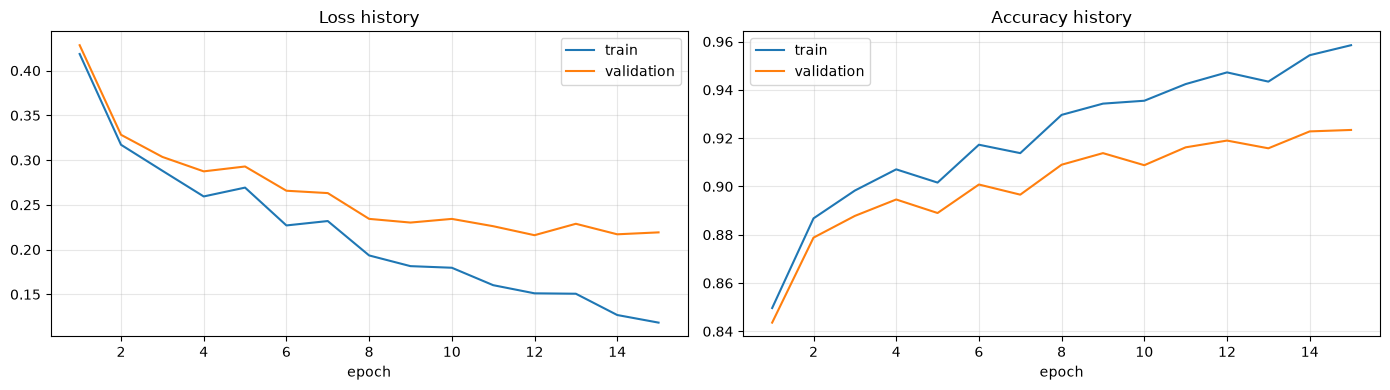

In [12]:
from IPython.display import display

model = baseline_fit["model"]
baseline_state = copy.deepcopy(model.state_dict())
# 監査対応: 同じrunのbaselineをRAMだけでなく保存する。再学習せず再検証できるようにする。
baseline_checkpoint_path = models_dir / "baseline_same_run.pt"
torch.save(baseline_state, baseline_checkpoint_path)


# 【.ipynb側】履歴を DataFrame / グラフにするのは実験ノートの仕事
df_training_history = pd.DataFrame(baseline_fit["history"])

print("Best epoch:", baseline_fit["best_epoch"])
print(f"Best validation loss: {baseline_fit['best_validation_loss']:.4f}")
display(df_training_history)

fig_learning, axes_learning = plt.subplots(1, 2, figsize=(14, 4))
axes_learning[0].plot(df_training_history["epoch"], df_training_history["train_loss"], label="train")
axes_learning[0].plot(df_training_history["epoch"], df_training_history["validation_loss"], label="validation")
axes_learning[0].set_title("Loss history")
axes_learning[0].set_xlabel("epoch")
axes_learning[0].legend()
axes_learning[0].grid(True, alpha=0.3)

axes_learning[1].plot(df_training_history["epoch"], df_training_history["train_acc"], label="train")
axes_learning[1].plot(df_training_history["epoch"], df_training_history["validation_acc"], label="validation")
axes_learning[1].set_title("Accuracy history")
axes_learning[1].set_xlabel("epoch")
axes_learning[1].legend()
axes_learning[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. MACsの見積もり

`conv2` を `kH×kW Conv(in → rank)` + `1×1 Conv(rank → out)` に、`fc1` を `Linear(in → rank)` + `Linear(rank → out)` に分解したときの、CNN 全体 MACs と削減率を出す。


In [13]:
# 層の SVD / MACs 見積もりは src/nn_compression から import 済み。


## 14. 固定 rank で Conv2 + fc1 を同時 SVD

03 で選んだ `fc1 rank=24` と、04 で選んだ `conv2 rank=28` を固定して同時に適用する。

この Notebook では rank sweep / Pareto / knee 選択は行わない。
SVD 直後の性能、モデル全体の Parameters / MACs、推論時間を Baseline と比較する。


In [14]:
CONV2_RANK = 28
FC1_RANK = 24

# 02〜04で rank 選択に使っていた後半5,000件は、
# 05では「rank選択」には使わず、固定rankモデルの最終Validation確認用に使う。
validation_loader_final = validation_loader_rank

# Baselineを最終Validationで評価
baseline_final_validation_loss, baseline_final_validation_acc = evaluate(
    model,
    validation_loader_final,
    criterion,
    device,
)

BENCH_WARMUP = 20
BENCH_REPEATS = 2000
# corrected: 原本は compressed 側の warmup/repeats が小さかった。同じ input_batch で揃える
inference_batch = take_inference_batch(validation_loader_final)
baseline_bench = benchmark_inference(
    model,
    device=device,
    warmup=BENCH_WARMUP,
    repeats=BENCH_REPEATS,
    input_batch=inference_batch,
    return_details=True,
)
baseline_time_s = baseline_bench["time_s"]
print(
    "benchmark batch_size",
    baseline_bench["batch_size"],
    "shape",
    baseline_bench["input_shape"],
    "warmup",
    BENCH_WARMUP,
    "repeats",
    BENCH_REPEATS,
)

# fc1 を rank=24 に分解したモデルを作る
compressed_model = factorize_named_linear(
    model,
    "fc1",
    FC1_RANK,
)

# conv2 を rank=28 に分解して同じモデルへ組み込む
compressed_model.conv2 = factorize_conv2d_layer(
    model.conv2,
    CONV2_RANK,
)

# SVD直後（Fine-tuning前）のValidation性能
svd_validation_loss, svd_validation_acc = evaluate(
    compressed_model,
    validation_loader_final,
    criterion,
    device,
)

# conv1 は圧縮しないが合計には入れる。空間サイズは Fashion-MNIST CNN
baseline_total_macs, compressed_total_macs, compute_reduction = estimate_cnn_macs(
    model,
    conv2_rank=CONV2_RANK,
    fc1_rank=FC1_RANK,
    verbose=False,
    conv_output_hw={
        "conv1": (28, 28),
        "conv2": (14, 14),
    },
)

compressed_time_s = benchmark_inference(
    compressed_model,
    device=device,
    warmup=BENCH_WARMUP,
    repeats=BENCH_REPEATS,
    input_batch=inference_batch,
)

compression_record = {
    "conv2_rank": CONV2_RANK,
    "fc1_rank": FC1_RANK,
    "parameters": count_parameters(compressed_model),
    "parameters_reduction": parameters_reduction(model, compressed_model),
    "baseline_macs": baseline_total_macs,
    "compressed_macs": compressed_total_macs,
    "compute_reduction": compute_reduction,
    "validation_loss": svd_validation_loss,
    "validation_acc": svd_validation_acc,
    "accuracy_drop": accuracy_drop(
        baseline_final_validation_acc,
        svd_validation_acc,
        verbose=False,
    ),
    "baseline_time_ms": baseline_time_s * 1000,
    "compressed_time_ms": compressed_time_s * 1000,
    "agreement": agreement(
        model,
        compressed_model,
        validation_loader_final,
        device,
    ),
    "logits_rmse": logits_rmse(
        model,
        compressed_model,
        validation_loader_final,
        device,
    ),
    "retained_energy_conv2": retained_energy(model.conv2, CONV2_RANK),
    "retained_energy_fc1": retained_energy(model.fc1, FC1_RANK),
    "benchmark_batch_size": baseline_bench["batch_size"],
    "benchmark_input_shape": baseline_bench["input_shape"],
    "benchmark_warmup": BENCH_WARMUP,
    "benchmark_repeats": BENCH_REPEATS,
}

df_compression_direct = pd.DataFrame([compression_record])
display(df_compression_direct)

print(
    f"conv2={CONV2_RANK}, fc1={FC1_RANK} | "
    f"Acc={svd_validation_acc:.4f} loss={svd_validation_loss:.4f} | "
    f"params={compression_record['parameters']:,} "
    f"MACs={compressed_total_macs:,} | "
    f"agreement={compression_record['agreement']:.4f}"
)


benchmark batch_size 256 shape (256, 1, 28, 28) warmup 20 repeats 2000


,conv2_rank,fc1_rank,parameters,parameters_reduction,baseline_macs,compressed_macs,compute_reduction,validation_loss,validation_acc,accuracy_drop,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_conv2,retained_energy_fc1,benchmark_batch_size,benchmark_input_shape,benchmark_warmup,benchmark_repeats
0,28,24,89994,0.786563,4241152,2237184,0.472506,0.241923,0.9116,0.0098,0.343286,0.342574,0.9716,0.691808,0.866444,0.864688,256,"(256, 1, 28, 28)",20,2000


conv2=28, fc1=24 | Acc=0.9116 loss=0.2419 | params=89,994 MACs=2,237,184 | agreement=0.9716


## 17. Fine-tuning（固定 rank）

`conv2 rank=28` と `fc1 rank=24` は 03・04 ですでに選択済みなので、05 では rank 探索を行わない。

SVD 直後のモデルを出発点に全パラメータを Fine-tuning する。
層構造が変わっているため optimizer は新しく作り、Early Stopping には `validation_loader_early_stop` を使う。


In [15]:
LEARNING_RATE = 3e-4
MAX_EPOCHS = 30

# 各実験で学習条件を再現できるように乱数状態とshuffle順を戻す。
set_seed(SEED)
# corrected: Fine-tuning も同じ SEED / 同じ shuffle 順から始める
loader_generator.manual_seed(SEED)

# SVDで作った重みをそのままFine-tuningの初期値にする。
fine_tuned_model = copy.deepcopy(compressed_model).to(device)

# SVD後はParameterオブジェクトが新しくなっているためoptimizerを作り直す。
fine_tune_optimizer = torch.optim.Adam(
    fine_tuned_model.parameters(),
    lr=LEARNING_RATE,
)

print(
    f"=== Fine-tuning: conv2={CONV2_RANK}, fc1={FC1_RANK} ==="
)

fine_tune_result = fit_with_early_stopping(
    model=fine_tuned_model,
    train_loader=train_loader,
    val_loader=validation_loader_early_stop,
    criterion=criterion,
    optimizer=fine_tune_optimizer,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    train_eval_loader=train_eval_loader,
    log_every_epoch=True,
)

final_model = fine_tune_result["model"]

df_fine_tuning_summary = pd.DataFrame(
    [
        {
            "conv2_rank": CONV2_RANK,
            "fc1_rank": FC1_RANK,
            "learning_rate": LEARNING_RATE,
            "best_epoch": fine_tune_result["best_epoch"],
            "best_validation_loss": fine_tune_result["best_validation_loss"],
        }
    ]
)
display(df_fine_tuning_summary)


=== Fine-tuning: conv2=28, fc1=24 ===


epoch=01 train_loss=0.1525 train_acc=0.9463 val_loss=0.2198 val_acc=0.9180


epoch=02 train_loss=0.1572 train_acc=0.9414 val_loss=0.2303 val_acc=0.9162


epoch=03 train_loss=0.1649 train_acc=0.9382 val_loss=0.2406 val_acc=0.9126


epoch=04 train_loss=0.1343 train_acc=0.9520 val_loss=0.2312 val_acc=0.9178
Early stopping at epoch 4


,conv2_rank,fc1_rank,learning_rate,best_epoch,best_validation_loss
0,28,24,0.0003,1,0.219785


## 18. Fine-tuning結果と Validation 比較

05 は候補モデルが1つだけなので、Pareto図や knee 図は使わない。

代わりに次の3点を可視化する。

- Fine-tuning の学習曲線：学習が収束しているか
- Baseline → SVD直後 → SVD+FT の Validation 差分：精度劣化を Fine-tuning で回復できたか
- Parameters / MACs の削減率：05 の「サイズ削減 + 計算量削減」という目的を確認する


,epoch,train_acc,train_loss,validation_loss,validation_acc
0,1,0.94634,0.152459,0.219785,0.9180
1,2,0.94140,0.157164,0.230323,0.9162
2,3,0.93820,0.164908,0.240585,0.9126
3,4,0.95202,0.134336,0.231161,0.9178


,stage,validation_loss,validation_acc,parameters,macs,delta_acc_pp,delta_loss
0,Baseline,0.220664,0.9214,421642,4241152,0.00,0.000000
1,SVD direct,0.241923,0.9116,89994,2237184,-0.98,0.021259
2,SVD + FT,0.225938,0.9188,89994,2237184,-0.26,0.005274


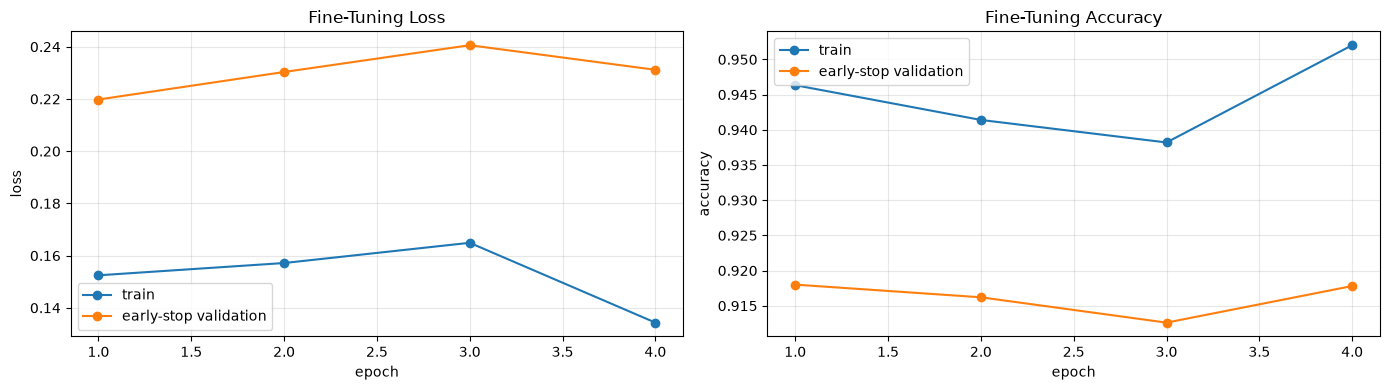

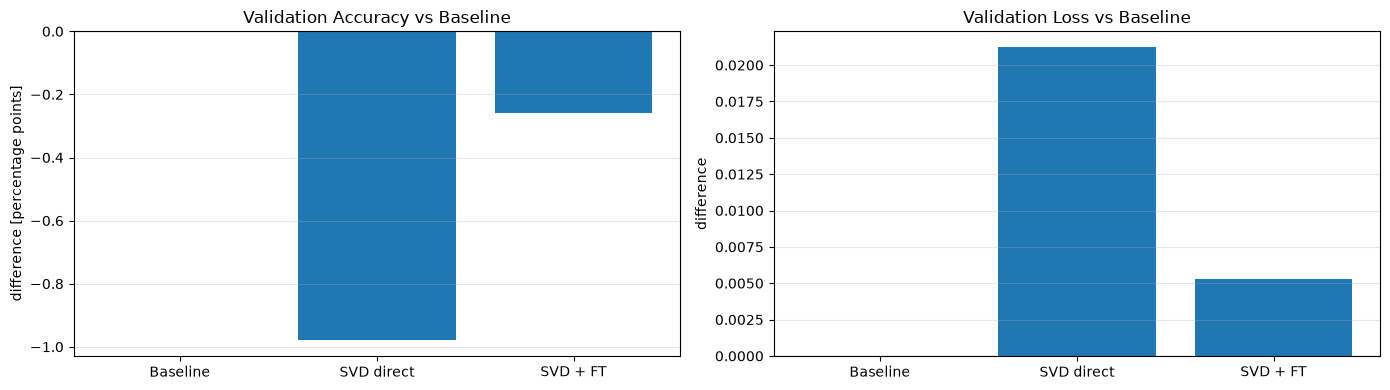

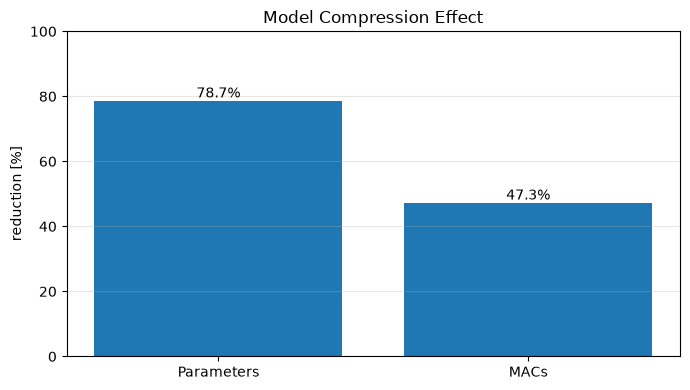

In [16]:
# Fine-tuning履歴
df_fine_tuning_history = pd.DataFrame(fine_tune_result["history"])

# 3段階を同じ final-validation 5,000件で比較する。
final_validation_loss, final_validation_acc = evaluate(
    final_model,
    validation_loader_final,
    criterion,
    device,
)

df_validation_comparison = pd.DataFrame(
    [
        {
            "stage": "Baseline",
            "validation_loss": baseline_final_validation_loss,
            "validation_acc": baseline_final_validation_acc,
            "parameters": count_parameters(model),
            "macs": baseline_total_macs,
        },
        {
            "stage": "SVD direct",
            "validation_loss": svd_validation_loss,
            "validation_acc": svd_validation_acc,
            "parameters": count_parameters(compressed_model),
            "macs": compressed_total_macs,
        },
        {
            "stage": "SVD + FT",
            "validation_loss": final_validation_loss,
            "validation_acc": final_validation_acc,
            "parameters": count_parameters(final_model),
            "macs": compressed_total_macs,
        },
    ]
)

df_validation_comparison["delta_acc_pp"] = (
    df_validation_comparison["validation_acc"]
    - baseline_final_validation_acc
) * 100
df_validation_comparison["delta_loss"] = (
    df_validation_comparison["validation_loss"]
    - baseline_final_validation_loss
)

display(df_fine_tuning_history)
display(df_validation_comparison)

# ------------------------------------------------------------
# Graph 1: Fine-tuning学習曲線
# ------------------------------------------------------------
fig_ft_history, axes_ft_history = plt.subplots(1, 2, figsize=(14, 4))

axes_ft_history[0].plot(
    df_fine_tuning_history["epoch"],
    df_fine_tuning_history["train_loss"],
    marker="o",
    label="train",
)
axes_ft_history[0].plot(
    df_fine_tuning_history["epoch"],
    df_fine_tuning_history["validation_loss"],
    marker="o",
    label="early-stop validation",
)
axes_ft_history[0].set_title("Fine-Tuning Loss")
axes_ft_history[0].set_xlabel("epoch")
axes_ft_history[0].set_ylabel("loss")
axes_ft_history[0].grid(True, alpha=0.3)
axes_ft_history[0].legend()

axes_ft_history[1].plot(
    df_fine_tuning_history["epoch"],
    df_fine_tuning_history["train_acc"],
    marker="o",
    label="train",
)
axes_ft_history[1].plot(
    df_fine_tuning_history["epoch"],
    df_fine_tuning_history["validation_acc"],
    marker="o",
    label="early-stop validation",
)
axes_ft_history[1].set_title("Fine-Tuning Accuracy")
axes_ft_history[1].set_xlabel("epoch")
axes_ft_history[1].set_ylabel("accuracy")
axes_ft_history[1].grid(True, alpha=0.3)
axes_ft_history[1].legend()

fig_ft_history.tight_layout()
plt.show()

# ------------------------------------------------------------
# Graph 2: BaselineからのValidation変化量
# 絶対accuracyを0始まりの棒で描くと差が見えにくいため、
# accuracyはpercentage point差、lossは差分で表示する。
# ------------------------------------------------------------
fig_validation_delta, axes_validation_delta = plt.subplots(1, 2, figsize=(14, 4))

axes_validation_delta[0].bar(
    df_validation_comparison["stage"],
    df_validation_comparison["delta_acc_pp"],
)
axes_validation_delta[0].axhline(0.0, linewidth=0.8)
axes_validation_delta[0].set_title("Validation Accuracy vs Baseline")
axes_validation_delta[0].set_ylabel("difference [percentage points]")
axes_validation_delta[0].grid(True, axis="y", alpha=0.3)

axes_validation_delta[1].bar(
    df_validation_comparison["stage"],
    df_validation_comparison["delta_loss"],
)
axes_validation_delta[1].axhline(0.0, linewidth=0.8)
axes_validation_delta[1].set_title("Validation Loss vs Baseline")
axes_validation_delta[1].set_ylabel("difference")
axes_validation_delta[1].grid(True, axis="y", alpha=0.3)

fig_validation_delta.tight_layout()
plt.show()

# ------------------------------------------------------------
# Graph 3: モデル全体の圧縮効果
# ------------------------------------------------------------
parameter_reduction_rate = parameters_reduction(model, compressed_model)

df_reduction = pd.DataFrame(
    {
        "metric": ["Parameters", "MACs"],
        "reduction_percent": [
            parameter_reduction_rate * 100,
            compute_reduction * 100,
        ],
    }
)

fig_reduction, axis_reduction = plt.subplots(figsize=(7, 4))
axis_reduction.bar(
    df_reduction["metric"],
    df_reduction["reduction_percent"],
)
axis_reduction.set_title("Model Compression Effect")
axis_reduction.set_ylabel("reduction [%]")
axis_reduction.set_ylim(0, 100)
axis_reduction.grid(True, axis="y", alpha=0.3)

for index, value in enumerate(df_reduction["reduction_percent"]):
    axis_reduction.text(
        index,
        value + 1.0,
        f"{value:.1f}%",
        ha="center",
    )

fig_reduction.tight_layout()
plt.show()


## 19. 最終 Test 評価

rank は 03・04 ですでに決定済みで、05 ではモデル選択を行わない。

Fine-tuning 済みの `conv2 rank=28 + fc1 rank=24` を最終モデルとし、ここで初めて Test 10,000件を Baseline と比較する。


In [17]:
# Baselineは同じ重みを新しいモデルへ読み直してTest評価する。
baseline_model_for_test = FashionMNISTCNN().to(device)
baseline_model_for_test.load_state_dict(baseline_state)

baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model_for_test,
    test_loader,
    criterion,
    device,
)

final_test_loss, final_test_acc = evaluate(
    final_model,
    test_loader,
    criterion,
    device,
)

baseline_params = count_parameters(baseline_model_for_test)
final_params = count_parameters(final_model)

df_test_comparison = pd.DataFrame(
    [
        {
            "model": "Baseline",
            "conv2_rank": "-",
            "fc1_rank": "-",
            "parameters": baseline_params,
            "macs": baseline_total_macs,
            "test_loss": baseline_test_loss,
            "test_acc": baseline_test_acc,
            "delta_test_acc_pp": 0.0,
            "delta_test_loss": 0.0,
        },
        {
            "model": "Conv2 + fc1 SVD + FT",
            "conv2_rank": CONV2_RANK,
            "fc1_rank": FC1_RANK,
            "parameters": final_params,
            "macs": compressed_total_macs,
            "test_loss": final_test_loss,
            "test_acc": final_test_acc,
            "delta_test_acc_pp": (
                final_test_acc - baseline_test_acc
            ) * 100,
            "delta_test_loss": (
                final_test_loss - baseline_test_loss
            ),
        },
    ]
)

print(
    f"Parameters: {baseline_params:,} -> {final_params:,} "
    f"({1 - final_params / baseline_params:.2%} reduction)"
)
print(
    f"MACs:       {baseline_total_macs:,} -> {compressed_total_macs:,} "
    f"({compute_reduction:.2%} reduction)"
)
print(
    f"Test acc:   {baseline_test_acc:.4f} -> {final_test_acc:.4f} "
    f"({(final_test_acc - baseline_test_acc) * 100:+.2f} pp)"
)

display(df_test_comparison)


Parameters: 421,642 -> 89,994 (78.66% reduction)
MACs:       4,241,152 -> 2,237,184 (47.25% reduction)
Test acc:   0.9128 -> 0.9133 (+0.05 pp)


,model,conv2_rank,fc1_rank,parameters,macs,test_loss,test_acc,delta_test_acc_pp,delta_test_loss
0,Baseline,-,-,421642,4241152,0.238263,0.9128,0.00,0.000000
1,Conv2 + fc1 SVD + FT,28,24,89994,2237184,0.241242,0.9133,0.05,0.002979


## 20. 結果の保存

05 では rank sweep / Pareto / knee の成果物は保存しない。

固定 rank の圧縮結果、Fine-tuning履歴、Validation比較、Test比較、3種類のグラフ、SVD直後モデルと最終Fine-tuningモデルを `05_cnn_conv_linear_svd` に保存する。


In [18]:
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

compression_summary_csv = results_dir / "compression_summary.csv"
fine_tuning_summary_csv = results_dir / "fine_tuning_summary.csv"
fine_tuning_history_csv = results_dir / "fine_tuning_history.csv"
validation_comparison_csv = results_dir / "validation_comparison.csv"
test_comparison_csv = results_dir / "test_comparison.csv"

df_compression_direct.to_csv(compression_summary_csv, index=False)
df_fine_tuning_summary.to_csv(fine_tuning_summary_csv, index=False)
df_fine_tuning_history.to_csv(fine_tuning_history_csv, index=False)
df_validation_comparison.to_csv(validation_comparison_csv, index=False)
df_test_comparison.to_csv(test_comparison_csv, index=False)

ft_history_figure_path = results_dir / "fine_tuning_history.png"
validation_delta_figure_path = results_dir / "validation_delta.png"
reduction_figure_path = results_dir / "compression_reduction.png"

fig_ft_history.savefig(
    ft_history_figure_path,
    dpi=150,
    bbox_inches="tight",
)
fig_validation_delta.savefig(
    validation_delta_figure_path,
    dpi=150,
    bbox_inches="tight",
)
fig_reduction.savefig(
    reduction_figure_path,
    dpi=150,
    bbox_inches="tight",
)

svd_direct_model_path = (
    models_dir
    / f"conv2-rank-{CONV2_RANK}_fc1-rank-{FC1_RANK}_svd_direct.pt"
)
final_model_path = (
    models_dir
    / f"conv2-rank-{CONV2_RANK}_fc1-rank-{FC1_RANK}_finetuned.pt"
)

torch.save(compressed_model.state_dict(), svd_direct_model_path)
torch.save(final_model.state_dict(), final_model_path)

metadata = {
    "experiment": EXPERIMENT_NAME,
    "conv2_rank": CONV2_RANK,
    "fc1_rank": FC1_RANK,
    "fine_tuning_learning_rate": LEARNING_RATE,
    "fine_tuning_best_epoch": int(fine_tune_result["best_epoch"]),
    "parameters_baseline": int(baseline_params),
    "parameters_final": int(final_params),
    "parameters_reduction": float(1 - final_params / baseline_params),
    "macs_baseline": int(baseline_total_macs),
    "macs_final": int(compressed_total_macs),
    "macs_reduction": float(compute_reduction),
    "baseline_test_loss": float(baseline_test_loss),
    "baseline_test_acc": float(baseline_test_acc),
    "final_test_loss": float(final_test_loss),
    "final_test_acc": float(final_test_acc),
}

metadata_path = results_dir / "metadata.json"
with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

for path in [
    compression_summary_csv,
    fine_tuning_summary_csv,
    fine_tuning_history_csv,
    validation_comparison_csv,
    test_comparison_csv,
    ft_history_figure_path,
    validation_delta_figure_path,
    reduction_figure_path,
    svd_direct_model_path,
    final_model_path,
    metadata_path,
]:
    print("saved:", path)


saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z\compression_summary.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z\fine_tuning_summary.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z\fine_tuning_history.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z\validation_comparison.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z\test_comparison.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z\fine_tuning_history.png
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_c

## 21. 保存先の確認

`results_dir` と `models_dir` が `05_cnn_conv_linear_svd` 用になっていることを確認する。


In [19]:
print("results_dir:", results_dir)
print("models_dir:", models_dir)

assert results_dir.name == EXPERIMENT_NAME
assert models_dir.name == EXPERIMENT_NAME


results_dir: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z
models_dir: D:\dev\nn-compression-svd-dmrg\models\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z


## 新規runの完全保存

以下は実験記録の保存用。過去runの欠落値を推定せず、このkernelで得た未丸め値・epoch履歴・checkpointを保存する。


In [20]:
# 新しいrunの成果物を不足なく残す。既存のhistorical出力先は使用しない。
import copy
import hashlib
import json
import platform
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import torch
from nn_compression.metrics import benchmark_inference, take_inference_batch, count_parameters

def _run_sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

_baseline_fit = globals().get("baseline_fit", globals().get("fit"))
assert _baseline_fit is not None
# baseline_stateは圧縮前のsnapshot。FT後checkpointから元重みを推定しない。
_baseline_model = copy.deepcopy(_baseline_fit["model"])
if "baseline_state" in globals():
    _baseline_model.load_state_dict(baseline_state)
torch.save(_baseline_model.state_dict(), models_dir / "baseline_same_run.pt")
pd.DataFrame(_baseline_fit["history"]).to_csv(results_dir / "baseline_history.csv", index=False)
_run_fit_summary = [{
    "stage": "baseline", "best_epoch": _baseline_fit["best_epoch"],
    "best_validation_loss": _baseline_fit["best_validation_loss"],
    "epochs_ran": len(_baseline_fit["history"]),
}]
_run_ft_records = []
if "df_fine_tuned_models" in globals():
    for _, _fit_row in df_fine_tuned_models.iterrows():
        _rank_fields = {c: int(_fit_row[c]) for c in ("fc1_rank", "fc2_rank", "conv2_rank") if c in _fit_row}
        _history_frame = pd.DataFrame(_fit_row["history"]).copy()
        _history_name = "_".join(f"{k}-{v}" for k, v in _rank_fields.items()) + "_ft_history.csv"
        _history_frame.to_csv(results_dir / _history_name, index=False)
        _run_fit_summary.append({
            "stage": "fine_tuning", **_rank_fields,
            "best_epoch": int(_fit_row["best_epoch"]),
            "best_validation_loss": float(_fit_row["best_validation_loss"]),
            "epochs_ran": len(_history_frame),
        })
        for _history_row in _history_frame.to_dict("records"):
            _run_ft_records.append({**_rank_fields, **_history_row})
elif "fine_tune_result" in globals():
    _history_frame = pd.DataFrame(fine_tune_result["history"])
    _history_frame.to_csv(results_dir / "fine_tuning_history.csv", index=False)
    _run_fit_summary.append({
        "stage": "fine_tuning", "conv2_rank": CONV2_RANK, "fc1_rank": FC1_RANK,
        "best_epoch": int(fine_tune_result["best_epoch"]),
        "best_validation_loss": float(fine_tune_result["best_validation_loss"]),
        "epochs_ran": len(_history_frame),
    })
    _run_ft_records = [{ "conv2_rank": CONV2_RANK, "fc1_rank": FC1_RANK, **r } for r in _history_frame.to_dict("records")]
if _run_ft_records:
    pd.DataFrame(_run_ft_records).to_csv(results_dir / "all_fine_tuning_history.csv", index=False)
pd.DataFrame(_run_fit_summary).to_csv(results_dir / "fit_summary.csv", index=False)

_rank_loader = globals().get("validation_loader_rank", globals().get("val_rank_loader"))
assert _rank_loader is not None
_run_inputs = take_inference_batch(_rank_loader)
_run_input_sha256 = hashlib.sha256(_run_inputs.numpy().tobytes()).hexdigest()
_run_warmup = globals().get("BENCH_WARMUP", 20)
_run_repeats = globals().get("BENCH_REPEATS", 2000)
for _name, _filename in (
    ("df_rank_results", "rank_sweep_results.csv"),
    ("df_pareto_view", "pareto_frontier.csv"),
    ("df_pareto_best", "selected_rank_neighbors.csv"),
):
    if _name in globals():
        _frame = globals()[_name].drop(columns=["model", "history"], errors="ignore").copy()
        if _name == "df_rank_results":
            _frame["benchmark_batch_size"] = len(_run_inputs)
            _frame["benchmark_input_shape"] = str(tuple(_run_inputs.shape))
            _frame["benchmark_input_sha256"] = _run_input_sha256
            _frame["benchmark_warmup"] = _run_warmup
            _frame["benchmark_repeats"] = _run_repeats
            _frame["benchmark_stage"] = "rank_sweep_before_finetuning"
        _frame.to_csv(results_dir / _filename, index=False)
_run_test = globals().get("df_test_comparison", globals().get("summary"))
assert _run_test is not None
_run_test.to_csv(results_dir / "test_comparison.csv", index=False)
torch.save(final_model.state_dict(), models_dir / "final_same_run.pt")
_run_benchmarks = []
for _trial in range(1, 4):
    _pairs = [("baseline", _baseline_model), ("final", final_model)]
    if _trial % 2 == 0:
        _pairs.reverse()
    for _label, _benchmark_model in _pairs:
        _details = benchmark_inference(
            _benchmark_model, device=device, input_batch=_run_inputs,
            warmup=_run_warmup, repeats=_run_repeats, return_details=True,
        )
        _run_benchmarks.append({
            "trial": _trial, "model": _label, "time_ms": _details["time_ms"],
            "parameters": count_parameters(_benchmark_model),
            "batch_size": _details["batch_size"], "input_shape": str(_details["input_shape"]),
            "warmup": _run_warmup, "repeats": _run_repeats,
            "stage": "final_after_finetuning" if _run_ft_records else "final_compression_only",
            "input_sha256": _run_input_sha256,
        })
_run_benchmark_frame = pd.DataFrame(_run_benchmarks)
_run_benchmark_frame.to_csv(results_dir / "final_model_benchmark.csv", index=False)
_run_csv_hashes = [
    {"path": p.relative_to(_run_root).as_posix(), "sha256": _run_sha256(p), "bytes": p.stat().st_size}
    for p in sorted(results_dir.iterdir()) if p.suffix in (".csv", ".png")
]
_run_checkpoints = [
    {"path": p.relative_to(_run_root).as_posix(), "sha256": _run_sha256(p), "bytes": p.stat().st_size}
    for p in sorted(models_dir.glob("*.pt"))
]
_run_notebook = _run_root / RUN_NOTEBOOK_RELATIVE
_run_code = json.loads(_run_notebook.read_text(encoding="utf-8"))["cells"]
_run_manifest = {
    "run_id": RUN_BATCH_ID, "experiment": EXPERIMENT_NAME,
    "source_notebook": RUN_SOURCE_RELATIVE, "executed_notebook": RUN_NOTEBOOK_RELATIVE,
    "status": "completed fresh run; NOT reconstruction of historical missing artifacts",
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "code_source_sha256": hashlib.sha256(json.dumps(
        ["".join(c["source"]) for c in _run_code if c["cell_type"] == "code"],
        ensure_ascii=False, separators=(",", ":"),
    ).encode("utf-8")).hexdigest(),
    "source_snapshot_sha256": RUN_SOURCE_SNAPSHOT_SHA256,
    "csv_precision": "direct pandas export of in-memory values; no display rounding",
    "seed": SEED,
    "split_lengths": [len(train_loader.dataset), len(_rank_loader.dataset)],
    "fit_summary": _run_fit_summary,
    "test_records": _run_test.to_dict("records"),
    "benchmark": {
        "warmup": _run_warmup, "repeats": _run_repeats, "trials": 3,
        "input_sha256": _run_input_sha256, "input_shape": list(_run_inputs.shape),
        "definition": "mean forward ms/batch per trial; eval/no_grad; H2D excluded; CUDA synchronized",
        "median_ms": _run_benchmark_frame.groupby("model")["time_ms"].median().to_dict(),
    },
    "environment": {
        "python": platform.python_version(), "torch": str(torch.__version__),
        "cuda": torch.version.cuda, "gpu": torch.cuda.get_device_name(device),
        "cudnn": torch.backends.cudnn.version(),
        "cudnn_benchmark": torch.backends.cudnn.benchmark,
        "cudnn_deterministic": torch.backends.cudnn.deterministic,
        "matmul_tf32": torch.backends.cuda.matmul.allow_tf32,
        "cudnn_tf32": torch.backends.cudnn.allow_tf32,
        "cpu_threads": torch.get_num_threads(),
    },
    "artifacts": _run_csv_hashes, "checkpoints": _run_checkpoints,
}
with (results_dir / "run_manifest.json").open("w", encoding="utf-8") as _f:
    json.dump(_run_manifest, _f, ensure_ascii=False, indent=2)
print("新規run完了:", EXPERIMENT_NAME)
print("成果物:", results_dir)
print("checkpoint:", models_dir)
print(_run_test.to_string(index=False))


新規run完了: 05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z
成果物: D:\dev\nn-compression-svd-dmrg\results\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z
checkpoint: D:\dev\nn-compression-svd-dmrg\models\10_svd\30_fashion_mnist_cnn\05_cnn_conv_linear_svd_corrected_rerun_20260912T074153Z
               model conv2_rank fc1_rank  parameters    macs  test_loss  test_acc  delta_test_acc_pp  delta_test_loss
            Baseline          -        -      421642 4241152   0.238263    0.9128               0.00         0.000000
Conv2 + fc1 SVD + FT         28       24       89994 2237184   0.241242    0.9133               0.05         0.002979
